In [ ]:
# imports
import sys
import numpy as np
import pandas as pd
import scipy.stats as stats
import scipy.io as sio

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
plt.style.use('scifigs.mplstyle')

sys.path.append('helpers/pcca_fa/')
import helpers.pcca_fa.pcca_fa_mdl as pf
from dual_pfc_funcs import getParams, load_dict, get_top_vec

# params
SAVE_FIG = True
data_path = 'preprocessed_data/'
params = getParams()
subjects, symbols, color_map = params['subjects'], params['markers'], params['color_map']

In [ ]:
pccafa = {}
for sub in subjects:
    pccafa = {**pccafa, **load_dict(data_path + sub + '_pccafa_cv15dim.pkl')}
fnames = pccafa.keys()

df = pd.DataFrame(columns=['SessionName','PctPosW1','PctPosW2','PctPosL1','PctPosL2','BadFlipW'])
for i, (sess, curr_dat) in enumerate(pccafa.items()):
    p = curr_dat['params']
    mdl = pf.pcca_fa()
    mdl.set_params(p)
    
    _,pct_w1,flipx1 = get_top_vec(p['W_1'],orth=True)
    _,pct_w2,flipx2 = get_top_vec(p['W_2'],orth=True)
    _,pct_l1,_ = get_top_vec(p['L_1'])
    _,pct_l2,_ = get_top_vec(p['L_2'])
    bad_flip = flipx1 ^ flipx2 # only counts sessions where one across-area vec was flipped without the other

    df2 = {'SessionName':sess,'PctPosW1':pct_w1*100,'PctPosW2':pct_w2*100,'PctPosL1':pct_l1*100,'PctPosL2':pct_l2*100,'BadFlipW':bad_flip}
    df.loc[len(df)] = df2
# df

print('Number of bad flips: {} of {}'.format(df['BadFlipW'].sum(), len(df)))

## Example session spatial layout of weights

Pct positive weights in across-area vec: 52.6%
Pct positive weights in within-area vec: 64.5%


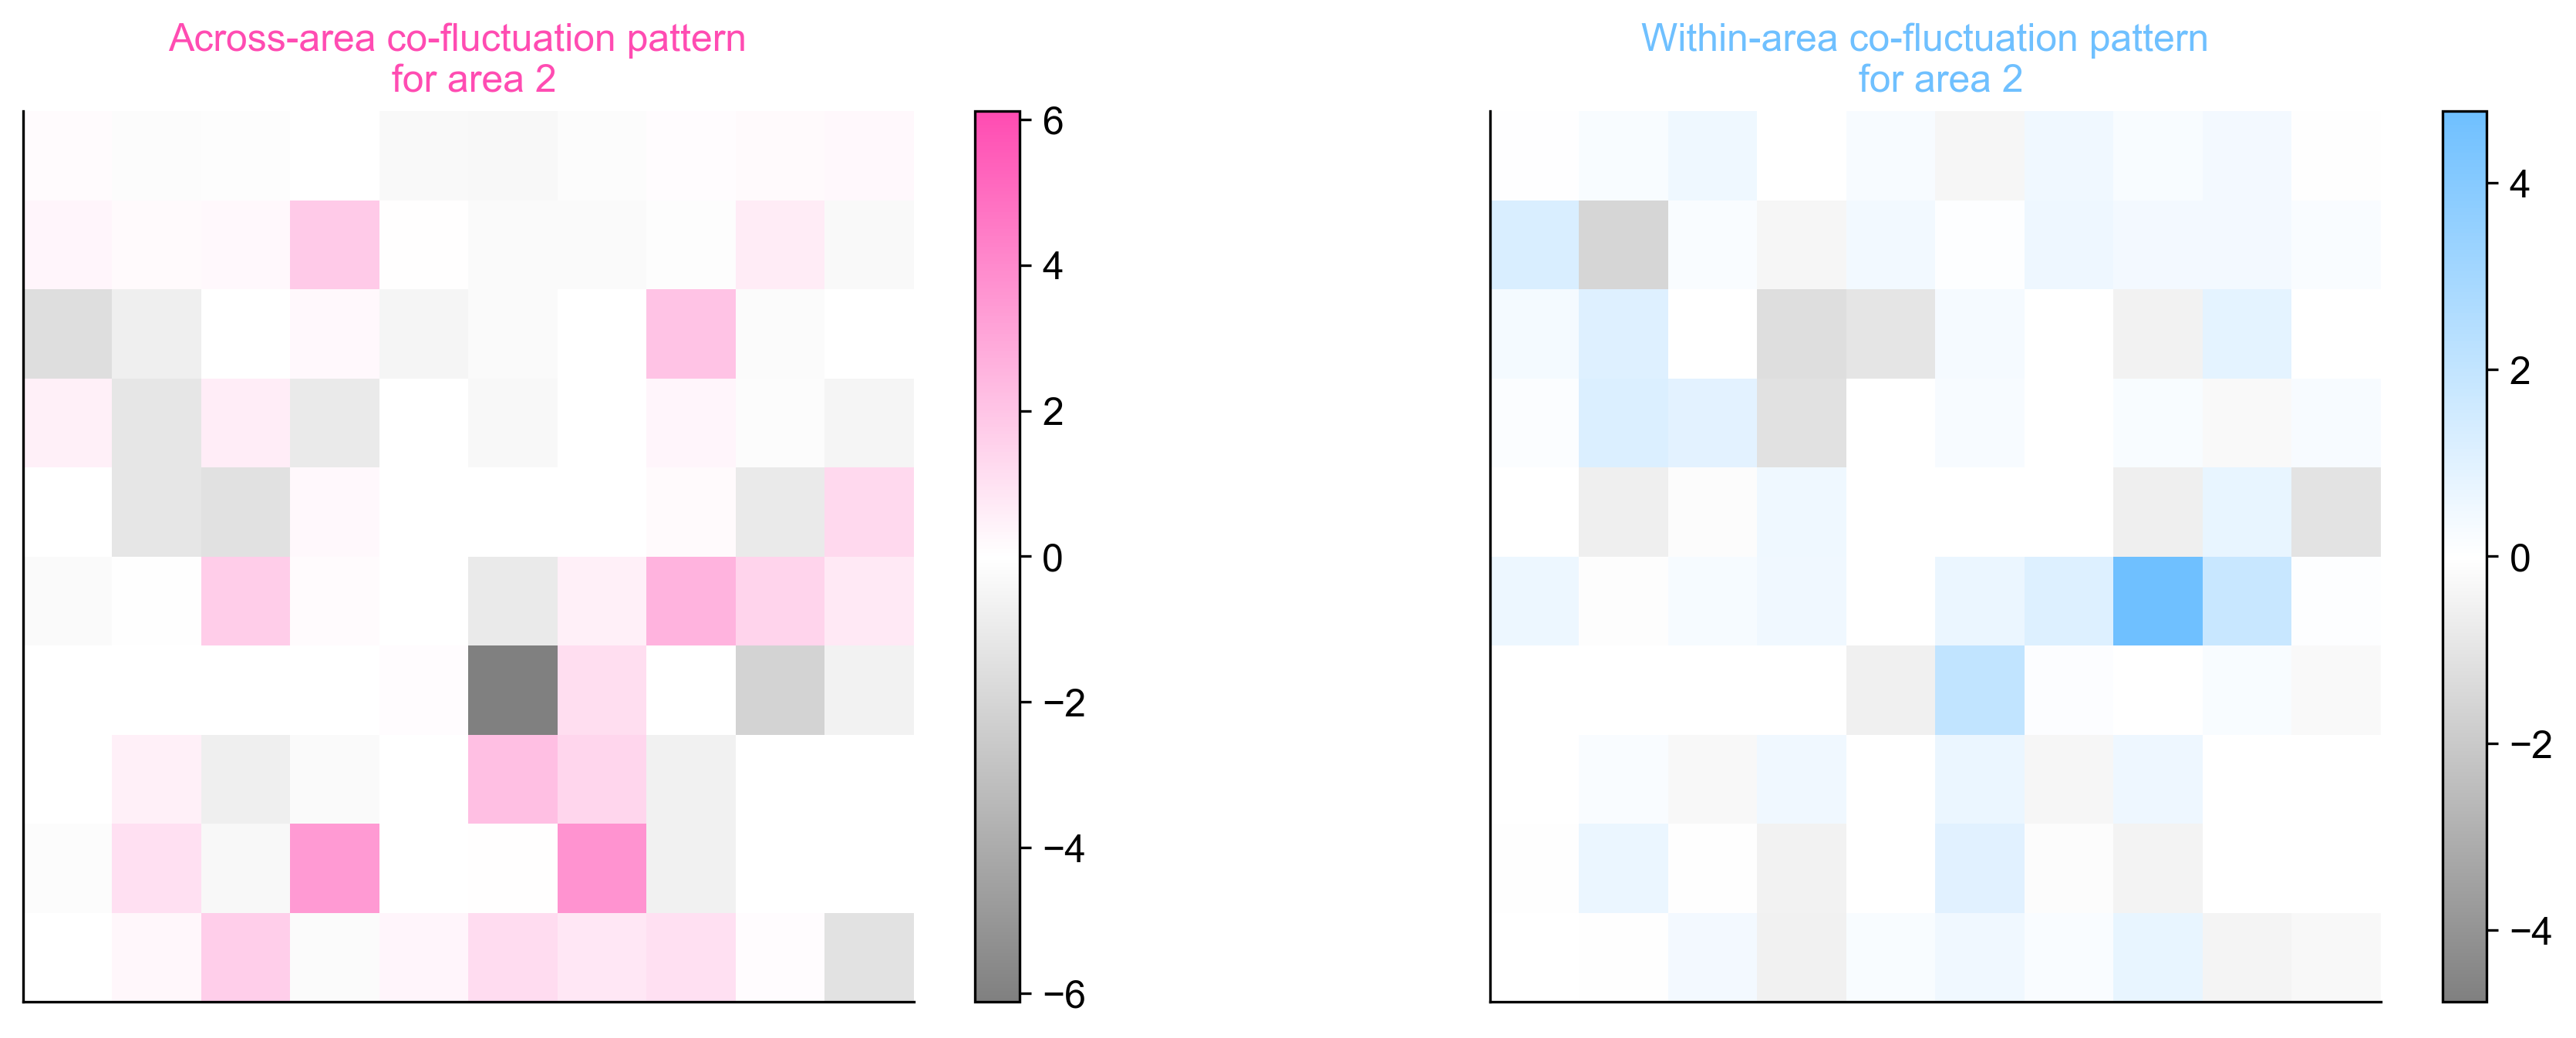

In [16]:
sub = 'satchel'
mat_fname = data_path + 'all_data_delay_' + sub + '.mat'
dat = sio.loadmat(mat_fname, squeeze_me=True)['all_data']

sess = 'Sa191127'
ex_params = pccafa[sess]['params']
n2 = ex_params['W_2'].shape[0] # RH

mdl = pf.pcca_fa()
mdl.set_params(ex_params)
_,top_w2,_,top_l2, = mdl.orthogonalize(across_mode='unpaired') # orthogonalize all latents!
top_w2 = top_w2[:,0]
top_l2 = top_l2[:,0]
if ((top_w2 >= 0).sum() / n2) < 0.5: top_w2 = -top_w2
if ((top_l2 >= 0).sum() / n2) < 0.5: top_l2 = -top_l2

# find percentage of positive weights in each vector
pct_pos_w2 = (top_w2 >= 0).sum() / n2
pct_pos_l2 = (top_l2 >= 0).sum() / n2
print('Pct positive weights in across-area vec: {:.1f}%'.format(pct_pos_w2*100))
print('Pct positive weights in within-area vec: {:.1f}%'.format(pct_pos_l2*100))

# Satchel RH Array Layout - from Blackrock
raw = """\
-1	2	1	3	4	6	8	10	14	20
65	66	33	34	7	9	11	12	16	18
67	68	35	36	5	17	13	23	-1	22
69	70	37	38	48	15	19	25	27	24
71	72	39	40	42	50	54	21	29	26
73	74	41	43	44	-1	52	62	31	28
75	76	45	47	51	56	58	60	64	30
77	78	82	49	53	55	57	59	61	-1
79	80	84	86	87	89	91	94	63	95
46	81	83	85	88	90	92	93	96	32
"""
ARRAY_COORDS = [[int(x) for x in row.split()] for row in raw.splitlines()]

# find which chans were removed in preprocessing
orig_chans = np.arange(1,97)
curr_dat = dat[sess].item()
remaining_chans = curr_dat['arr'].item()['RH_chans'].item().astype(int) - 96

# populate weights into grid and plot
weight_grid_w2 = np.full((10,10),np.nan)
weight_grid_l2 = np.full((10,10),np.nan)
for i_chan,chan in enumerate(remaining_chans):
    loc = np.argwhere(np.array(ARRAY_COORDS) == chan)[0]
    weight_grid_w2[loc[0],loc[1]] = top_w2[i_chan]
    weight_grid_l2[loc[0],loc[1]] = top_l2[i_chan]

# plot
across_colors = [(0, 'gray'), (0.5, 'white'), (1, color_map['across'])]
within2_colors = [(0, 'gray'), (0.5, 'white'), (1, color_map['within1'])]

across_cmap = mcolors.LinearSegmentedColormap.from_list("my_diverging_cmap", across_colors)
within2_cmap = mcolors.LinearSegmentedColormap.from_list("my_diverging_cmap", within2_colors)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

im0 = axes[0].imshow(weight_grid_w2, cmap=across_cmap, vmin=-np.max(np.abs(top_w2)), vmax=np.max(np.abs(top_w2)))
axes[0].set_title('Across-area co-fluctuation pattern  \n for area 2', color=color_map['across'])
axes[0].set_yticks([]),axes[0].set_xticks([])
fig.colorbar(im0, ax=axes[0], orientation='vertical')

im2 = axes[1].imshow(weight_grid_l2, cmap=within2_cmap, vmin=-np.max(np.abs(top_l2)), vmax=np.max(np.abs(top_l2)))
axes[1].set_title('Within-area co-fluctuation pattern  \n for area 2', color=color_map['within1'])
axes[1].set_yticks([]),axes[1].set_xticks([])
fig.colorbar(im2, ax=axes[1], orientation='vertical')

if SAVE_FIG:
    pdf = PdfPages('figs/ex_spatial_weights.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()

## Across session proportion of positive weights

/var/folders/n6/25pbyfj56mj_j3jqsv8rcw480000gn/T/ipykernel_22888/176681611.py:36: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


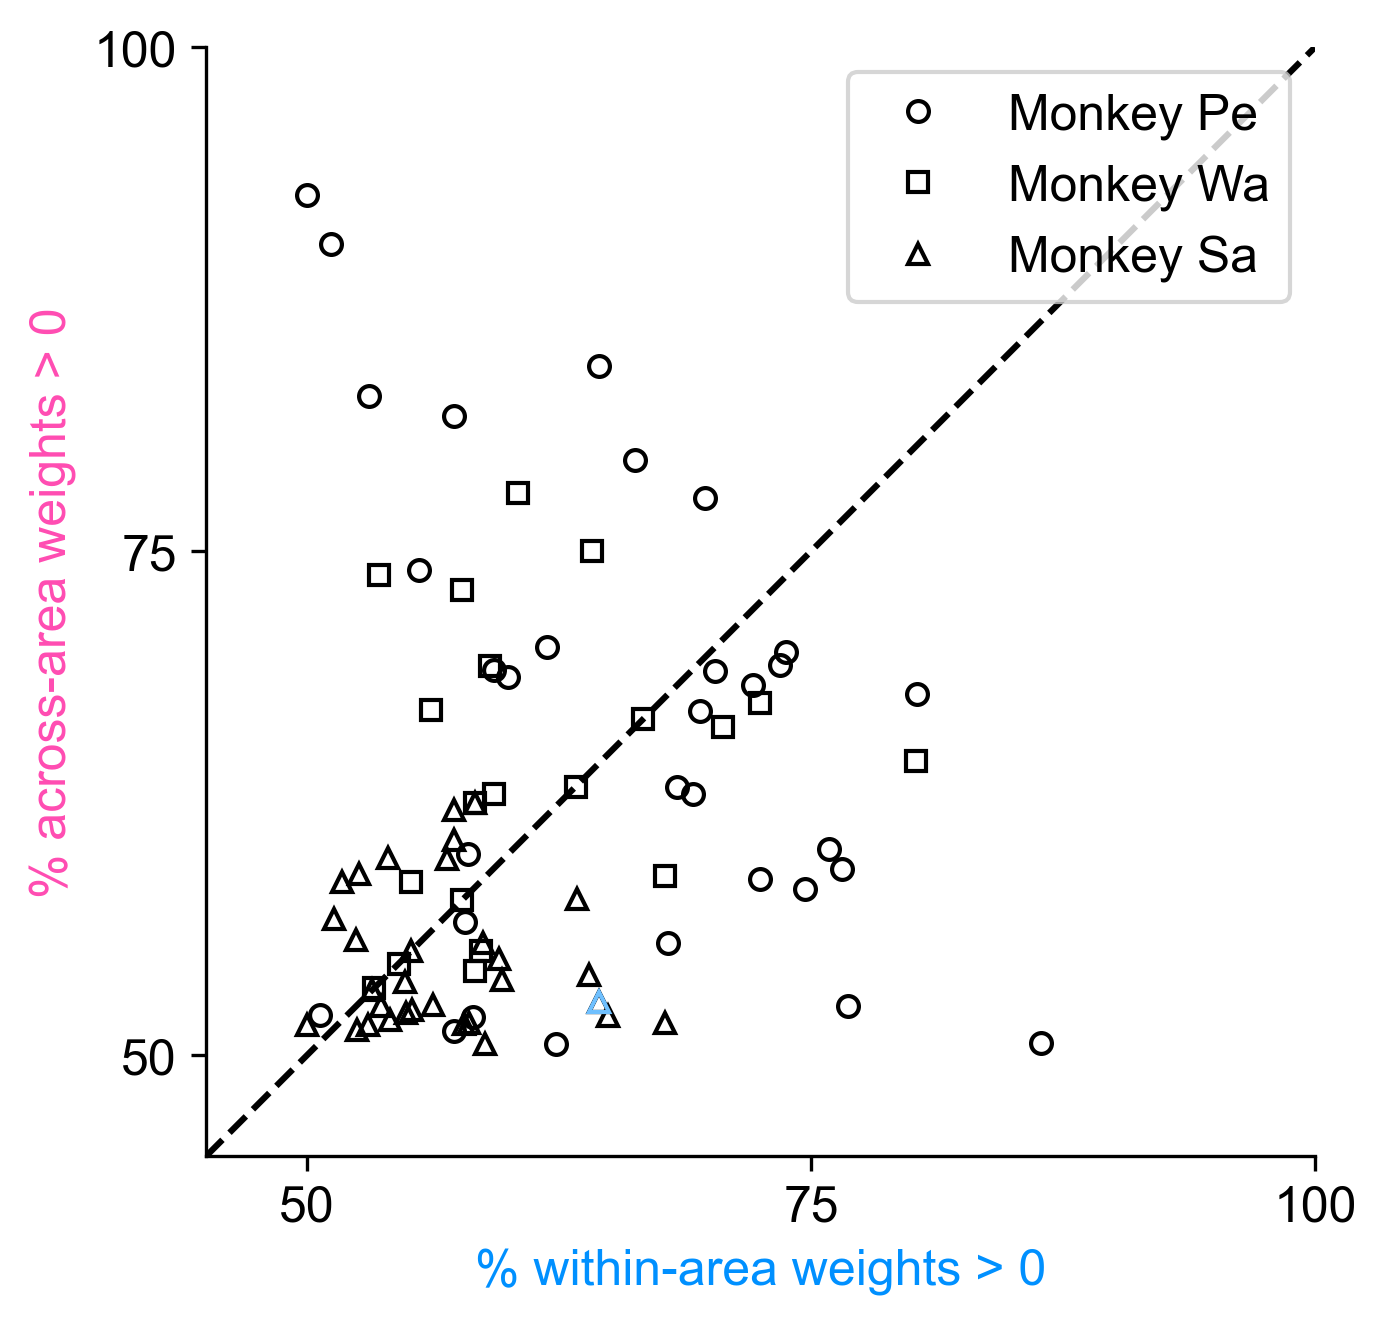

In [25]:
# loop through each monkey
ms = 5
fig,ax = plt.subplots()

for sub,sym in zip(subjects,symbols):
    sub_prefix = sub[:2].title()
    filt = [sub_prefix in s for s in df['SessionName']]
    tmp_df = df[filt]
    ax.plot(tmp_df['PctPosL1'], tmp_df['PctPosW1'], color='black', marker=sym, markersize=ms, fillstyle='none', ls='', label='Monkey {}'.format(sub_prefix))
    ax.plot(tmp_df['PctPosL2'], tmp_df['PctPosW2'], color='black', marker=sym, markersize=ms, fillstyle='none', ls='')

# plot example session
sym_idx = np.where([s=='satchel' for s in subjects])[0][0]
symbols[sym_idx]
ax.plot(pct_pos_l2*100, pct_pos_w2*100, color=color_map['within1'], marker=symbols[sym_idx], markersize=ms, fillstyle='none')

# make plots pretty and display them
lims = [45,100]
ticks = np.arange(50,105,25)
ax.legend(loc='upper right')
ax.set_xlabel('% within-area weights > 0', color=color_map['within'])
ax.set_ylabel('% across-area weights > 0', color=color_map['across'])
ax.plot(lims,lims,'k--')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_aspect('equal')

SAVE_FIG = False
if SAVE_FIG:
    pdf = PdfPages('figs/pos_weights_all_sess.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()

In [ ]:
# statistics
alpha = 0.01

# test if across and within are different across all monkeys
pct_within = np.concatenate((df['PctPosL1'], df['PctPosL2']))
pct_across = np.concatenate((df['PctPosW1'], df['PctPosW2']))
print('pct pos: across={:.3f} +/- {:.3f} s.e.m., within={:.3f} +/- {:.3f} s.e.m.'.format(np.mean(pct_across),stats.sem(pct_across),pct_within.mean(),stats.sem(pct_within)))

_,p = stats.ttest_rel(pct_across,pct_within,alternative='two-sided')
print()
print('Across different than within?')
print('Pooled, pct pos: {}, p = {:5f}'.format(p<alpha,p))
print()
for sub in subjects:
    sub_prefix = sub[:2].title()
    filt = [sub_prefix in s for s in df['SessionName']]
    tmp_df = df[filt]

    pct_within = np.concatenate((tmp_df['PctPosL1'], tmp_df['PctPosL2']))
    pct_across = np.concatenate((tmp_df['PctPosW1'], tmp_df['PctPosW2']))

    # test if across and within are different for this monkey
    _,p = stats.ttest_rel(pct_across,pct_within,alternative='two-sided')
    print('Monkey {:s}, pct pos: {}, p = {:5f}'.format(sub_prefix,p<alpha,p))